In [ ]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================
!pip install transformers torch scikit-learn matplotlib seaborn

import json
import re
import os
import zipfile
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from collections import defaultdict
from tqdm import tqdm
from google.colab import files

In [ ]:
# ============================================================
# CONFIG
# ============================================================
MODEL_NAME  = "google/muril-base-cased"
MAX_LEN     = 128
BATCH_SIZE  = 8
EPOCHS      = 8
LR          = 2e-5
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
# ============================================================
# LOAD DATA
# ============================================================
print("\n" + "=" * 60)
print("LOADING DATA")
print("=" * 60)

with open("marathi_wsd_dataset_filtered (1).json", "r", encoding="utf-8") as f:
    raw = json.load(f)

# ✅ Fix — normalize all sense_id keys to string
# Prevents key type mismatch (int vs str) which causes
# model to train on word name instead of actual gloss
sense_gloss = {str(item["sense_id"]): item["gloss"] for item in raw}

# ✅ Fix — normalize sense_id to string in word_senses too
word_senses = defaultdict(set)
for item in raw:
    word_senses[item["target_word"]].add(str(item["sense_id"]))
word_senses = {w: list(s) for w, s in word_senses.items()}

print(f"Total rows loaded: {len(raw)}")
print(f"Total unique senses: {len(sense_gloss)}")
print(f"Total ambiguous words: {len(word_senses)}")
for word, senses in word_senses.items():
    print(f"  {word}: {len(senses)} senses")


LOADING DATA
Total rows loaded: 50242
Total unique senses: 50
Total ambiguous words: 16
  डोळा: 5 senses
  मार्ग: 3 senses
  वाट: 3 senses
  वाटणे: 3 senses
  देणे: 3 senses
  भाव: 3 senses
  योग: 3 senses
  अर्थ: 3 senses
  नाव: 3 senses
  वर: 3 senses
  बरोबर: 3 senses
  मंद: 3 senses
  वार: 3 senses
  पाठ: 3 senses
  अंक: 3 senses
  गुण: 3 senses


In [ ]:
# ============================================================
# DATASET CLASS
# ============================================================
# Each row = (sentence + gloss) pair with label 0 or 1
# label=1 → this gloss is the CORRECT sense for this sentence
# label=0 → this gloss is a WRONG sense for this sentence
#
# The model learns to answer:
# "Does this sentence match this sense definition?"
# ============================================================
class BinaryWSDDataset(Dataset):
    def __init__(self, items, tokenizer, max_len):
        self.items     = items
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]

        # ✅ Fix — use str() to ensure consistent key lookup
        gloss = sense_gloss.get(str(item["sense_id"]), item["target_word"])

        enc = self.tokenizer(
            item["sentence"],
            gloss,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "token_type_ids": enc.get(
                "token_type_ids",
                torch.zeros(self.max_len, dtype=torch.long)
            ).squeeze(),
            "label": torch.tensor(item["label"], dtype=torch.long)
        }


In [ ]:
# ============================================================
# MODEL DEFINITION
# ============================================================
# MuRIL encoder reads (sentence + gloss) pair
# Projector maps CLS vector → 256-dim sense space
# Classifier gives final binary decision (match or not)
# ============================================================
class WSDModel(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden          = self.encoder.config.hidden_size  # 768 for MuRIL
        self.projector  = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256)
        )
        self.classifier = nn.Linear(256, 2)  # binary: correct sense or not

    def encode(self, input_ids, attention_mask, token_type_ids):
        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        cls = out.last_hidden_state[:, 0, :]  # CLS token
        return self.projector(cls)             # (B, 256)

    def forward(self, input_ids, attention_mask, token_type_ids):
        emb = self.encode(input_ids, attention_mask, token_type_ids)
        return self.classifier(emb)            # (B, 2) logits



In [ ]:
import json

# Bring in necessary global configurations for this cell
MODEL_NAME  = "google/muril-base-cased"
MAX_LEN     = 128

# ============================================================
# LOAD CUSTOM TRAIN / VAL / TEST SPLITS
# ============================================================
print("\n" + "=" * 60)
print("LOADING CUSTOM TRAIN / VAL / TEST DATA")
print("=" * 60)

# Load train split
with open("train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)

# Load val split
with open("val.json", "r", encoding="utf-8") as f:
    val_data = json.load(f)

# Load test split
with open("test.json", "r", encoding="utf-8") as f:
    test_data = json.load(f)

print(f"Train rows: {len(train_data)}")
print(f"Val rows:   {len(val_data)}")
print(f"Test rows:  {len(test_data)}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = BinaryWSDDataset(train_data, tokenizer, MAX_LEN)
val_ds   = BinaryWSDDataset(val_data,   tokenizer, MAX_LEN)
test_ds  = BinaryWSDDataset(test_data,  tokenizer, MAX_LEN)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"\nTrain batches: {len(train_dl)}")
print(f"Val batches:   {len(val_dl)}")
print(f"Test batches:  {len(test_dl)}")


LOADING CUSTOM TRAIN / VAL / TEST DATA
Train rows: 35171
Val rows:   7529
Test rows:  7542

Train batches: 4397
Val batches:   942
Test batches:  943


In [ ]:
# ============================================================
# LOSS FUNCTION
# ============================================================
# Weighted CrossEntropy handles label imbalance
# In WSD: label=0 rows >> label=1 rows
# Because each sentence has 1 correct sense but N-1 wrong senses
# We upweight label=1 to compensate
# ============================================================
avg_senses = np.mean([len(v) for v in word_senses.values()])
pos_weight = torch.tensor([1.0, float(avg_senses - 1)]).to(DEVICE)
ce_loss_fn = nn.CrossEntropyLoss(weight=pos_weight)

print(f"\nAverage senses per word: {avg_senses:.1f}")
print(f"Loss weight for label=1: {float(avg_senses - 1):.1f}")



Average senses per word: 3.1
Loss weight for label=1: 2.1


In [ ]:
# ============================================================
# TRAINING LOOP
# ============================================================

from tqdm.auto import tqdm

model     = WSDModel(MODEL_NAME).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, total_steps // 10),
    num_training_steps=total_steps
)

best_f1        = 0.0
train_loss_log = []
val_loss_log   = []
val_f1_log     = []

print("\n" + "=" * 60)
print("TRAINING STARTED")
print("=" * 60)

# ✅ Outer epoch bar — tracks overall progress across all 8 epochs
epoch_bar = tqdm(range(EPOCHS), desc="Overall Progress", unit="epoch")

for epoch in epoch_bar:

    # ── Train ──────────────────────────────────────────────
    model.train()
    total_train_loss = 0.0

    # ✅ Inner train bar — updates in place, disappears when done
    train_bar = tqdm(
        train_dl,
        desc=f"  Epoch {epoch+1}/{EPOCHS} Train",
        leave=False,
        unit="batch"
    )

    for batch in train_bar:
        optimizer.zero_grad()

        logits = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE)
        )
        loss = ce_loss_fn(logits, batch["label"].to(DEVICE))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()

        # ✅ Show live loss inside the train bar
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_dl)
    train_loss_log.append(avg_train_loss)

    # ── Validate ───────────────────────────────────────────
    model.eval()
    total_val_loss = 0.0
    all_preds      = []
    all_labels     = []

    # ✅ Inner val bar — updates in place, disappears when done
    val_bar = tqdm(
        val_dl,
        desc=f"  Epoch {epoch+1}/{EPOCHS} Val  ",
        leave=False,
        unit="batch"
    )

    with torch.no_grad():
        for batch in val_bar:
            logits = model(
                batch["input_ids"].to(DEVICE),
                batch["attention_mask"].to(DEVICE),
                batch["token_type_ids"].to(DEVICE)
            )

            val_loss = ce_loss_fn(logits, batch["label"].to(DEVICE))
            total_val_loss += val_loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["label"].cpu().numpy())

            # ✅ Show live val loss inside the val bar
            val_bar.set_postfix(loss=f"{val_loss.item():.4f}")

    avg_val_loss = total_val_loss / len(val_dl)
    val_loss_log.append(avg_val_loss)

    f1 = f1_score(all_labels, all_preds, average="macro")
    val_f1_log.append(f1)

    # ✅ Update outer epoch bar with summary metrics
    epoch_bar.set_postfix(
        train_loss=f"{avg_train_loss:.4f}",
        val_loss=f"{avg_val_loss:.4f}",
        f1=f"{f1:.4f}"
    )

    # ✅ Clean summary printed once per epoch — stays permanently
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss : {avg_train_loss:.4f}")
    print(f"  Val Loss   : {avg_val_loss:.4f}")
    print(f"  Val F1     : {f1:.4f}")

    # Overfitting warning
    if len(train_loss_log) > 1:
        if val_loss_log[-1] > val_loss_log[-2] and train_loss_log[-1] < train_loss_log[-2]:
            print(f"  ⚠ Warning: Val loss increasing while Train loss decreasing — possible overfitting")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_muril_wsd.pt")
        print(f"  ✅ Saved best model (F1={f1:.4f})")

print(f"\nBest Val Macro-F1: {best_f1:.4f}")

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



TRAINING STARTED


...

  Epoch 7/8 Val  :   0%|          | 0/942 [00:00<?, ?batch/s]


Epoch 7/8
  Train Loss : 0.2644
  Val Loss   : 0.5380
  Val F1     : 0.8690
  ⚠ Warning: Val loss increasing while Train loss decreasing — possible overfitting


  Epoch 8/8 Train:   0%|          | 0/4397 [00:00<?, ?batch/s]

  Epoch 8/8 Val  :   0%|          | 0/942 [00:00<?, ?batch/s]


Epoch 8/8
  Train Loss : 0.2480
  Val Loss   : 0.5912
  Val F1     : 0.8690
  ⚠ Warning: Val loss increasing while Train loss decreasing — possible overfitting

Best Val Macro-F1: 0.8704


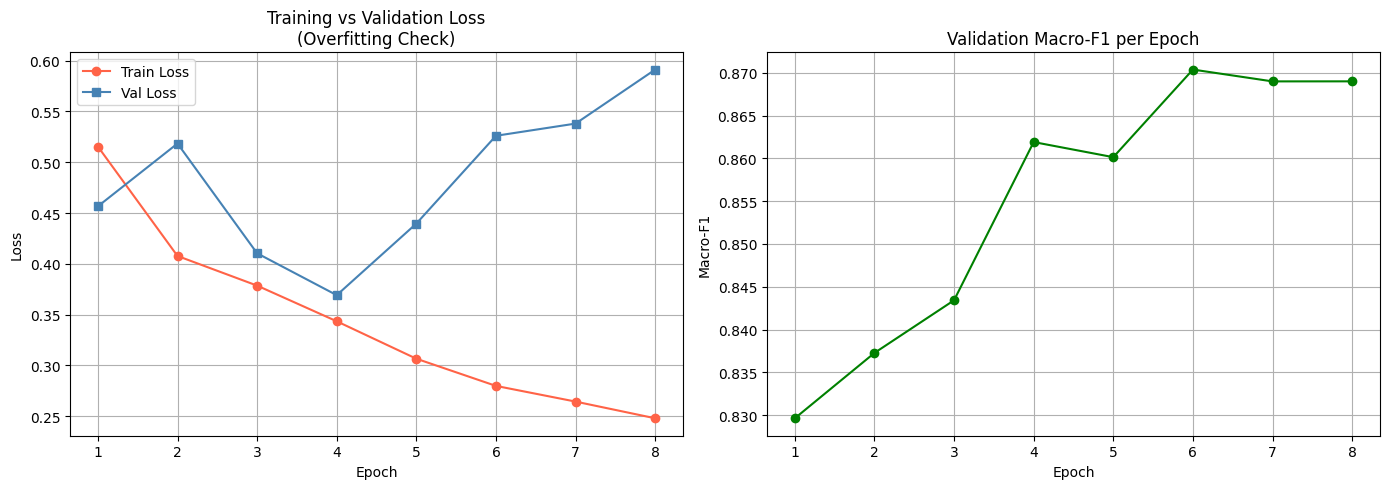

Training curves saved


In [ ]:

# ============================================================
# PLOT TRAINING VS VALIDATION LOSS (OVERFITTING CHECK)
# ============================================================
# If both curves go down together → model is learning well
# If train loss goes down but val loss goes up → overfitting
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, EPOCHS+1), train_loss_log, label='Train Loss', marker='o', color='tomato')
ax1.plot(range(1, EPOCHS+1), val_loss_log,   label='Val Loss',   marker='s', color='steelblue')
ax1.set_title("Training vs Validation Loss\n(Overfitting Check)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, EPOCHS+1), val_f1_log, marker='o', color='green')
ax2.set_title("Validation Macro-F1 per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro-F1")
ax2.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Training curves saved")

In [ ]:
# ============================================================
# FINAL EVALUATION ON UNSEEN TEST SET
# ============================================================
# This is the ONLY true measure of model performance
# The test set was never seen during training or validation
# Loading the BEST checkpoint (not last epoch)
# ============================================================
print("\n" + "=" * 60)
print("FINAL EVALUATION ON UNSEEN TEST SET")
print("=" * 60)

best_ckpt = torch.load("best_muril_wsd.pt", map_location=DEVICE)
model.load_state_dict(best_ckpt)
model.eval()

all_test_preds  = []
all_test_labels = []

with torch.no_grad():
    for batch in tqdm(test_dl, desc="Testing"):
        logits = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE)
        )
        preds = torch.argmax(logits, dim=1)
        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(batch["label"].cpu().numpy())

test_acc = accuracy_score(all_test_labels, all_test_preds)
test_f1  = f1_score(all_test_labels, all_test_preds, average="macro")

print(f"\nFinal Test Accuracy : {test_acc*100:.2f}%")
print(f"Final Test Macro-F1 : {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(
    all_test_labels, all_test_preds,
    target_names=["Wrong Sense", "Correct Sense"]
))




FINAL EVALUATION ON UNSEEN TEST SET


Testing:   0%|          | 0/943 [00:00<?, ?it/s]


Final Test Accuracy : 87.89%
Final Test Macro-F1 : 0.8578

Classification Report:
               precision    recall  f1-score   support

  Wrong Sense       0.89      0.94      0.91      5078
Correct Sense       0.86      0.75      0.80      2464

     accuracy                           0.88      7542
    macro avg       0.87      0.85      0.86      7542
 weighted avg       0.88      0.88      0.88      7542



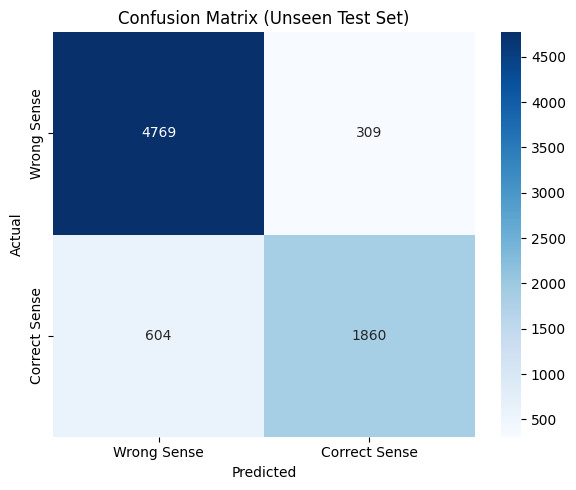

Confusion matrix saved


In [ ]:

# ============================================================
# CONFUSION MATRIX ON TEST SET
# ============================================================
cm = confusion_matrix(all_test_labels, all_test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Wrong Sense", "Correct Sense"],
    yticklabels=["Wrong Sense", "Correct Sense"]
)
plt.title("Confusion Matrix (Unseen Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved")


In [ ]:
# ============================================================
# PER-WORD ACCURACY ON TEST SET
# ============================================================
# Standard WSD evaluation metric
# Shows which words the model handles well vs poorly
# Examiners expect this breakdown
# ============================================================
print("\n" + "=" * 60)
print("PER-WORD ACCURACY ON TEST SET")
print("=" * 60)

per_word_test = defaultdict(lambda: {"correct": 0, "total": 0})

model.eval()
test_item_idx = 0

with torch.no_grad():
    for batch in tqdm(test_dl, desc="Per-word evaluation"):
        logits = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE)
        )
        preds  = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch["label"].cpu().numpy()

        batch_size = len(labels)
        for i in range(batch_size):
            item = test_data[test_item_idx + i]
            word = item["target_word"]
            per_word_test[word]["total"] += 1
            if preds[i] == labels[i]:
                per_word_test[word]["correct"] += 1
        test_item_idx += batch_size

print(f"\n{'Word':<15} {'Accuracy Bar':<25} {'Score':<8} {'Correct/Total'}")
print("-" * 60)
for word, res in sorted(per_word_test.items()):
    acc = res["correct"] / res["total"] if res["total"] > 0 else 0
    bar = "█" * int(acc * 20) + "░" * (20 - int(acc * 20))
    print(f"  {word:<13} [{bar}] {acc:.3f}   ({res['correct']}/{res['total']})")



PER-WORD ACCURACY ON TEST SET


Per-word evaluation:   0%|          | 0/943 [00:00<?, ?it/s]


Word            Accuracy Bar              Score    Correct/Total
------------------------------------------------------------
  अंक           [█████████████░░░░░░░] 0.689   (91/132)
  अर्थ          [█████████████████░░░] 0.864   (210/243)
  गुण           [█████████████░░░░░░░] 0.673   (99/147)
  डोळा          [████████████████░░░░] 0.803   (301/375)
  देणे          [██████████████████░░] 0.902   (1440/1596)
  नाव           [████████████████░░░░] 0.824   (225/273)
  पाठ           [██████████████████░░] 0.923   (191/207)
  बरोबर         [█████████████░░░░░░░] 0.681   (98/144)
  भाव           [████████████████░░░░] 0.843   (172/204)
  मंद           [██████████████░░░░░░] 0.738   (144/195)
  मार्ग         [█████████████████░░░] 0.881   (214/243)
  योग           [██████████████░░░░░░] 0.742   (178/240)
  वर            [███████████████████░] 0.971   (2686/2766)
  वाट           [███████████████░░░░░] 0.783   (275/351)
  वाटणे         [█████████████░░░░░░░] 0.674   (95/141)
  वार           [█

In [ ]:
# ============================================================
# PER-WORD PRECISION, RECALL, F1 — MuRIL
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score
from collections import defaultdict

print("\n" + "=" * 60)
print("PER-WORD PRECISION / RECALL / F1 ON TEST SET")
print("=" * 60)

# Group test predictions by word
per_word_labels = defaultdict(list)
per_word_preds  = defaultdict(list)

model.eval()
test_item_idx = 0

with torch.no_grad():
    for batch in tqdm(test_dl, desc="Evaluating", leave=False):
        logits = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE)
        )
        preds  = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch["label"].cpu().numpy()

        batch_size = len(labels)
        for i in range(batch_size):
            word = test_data[test_item_idx + i]["target_word"]
            per_word_labels[word].append(int(labels[i]))
            per_word_preds[word].append(int(preds[i]))
        test_item_idx += batch_size

# ── Print table ──────────────────────────────────────────
print(f"\n{'Word':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 58)

all_words_labels = []
all_words_preds  = []

for word in sorted(per_word_labels.keys()):
    y_true = per_word_labels[word]
    y_pred = per_word_preds[word]

    p  = precision_score(y_true, y_pred, average="macro", zero_division=0)
    r  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    support = len(y_true)

    print(f"  {word:<13} {p:>10.4f} {r:>10.4f} {f1:>10.4f} {support:>10}")

    all_words_labels.extend(y_true)
    all_words_preds.extend(y_pred)

# ── Overall row ───────────────────────────────────────────
print("-" * 58)
overall_p  = precision_score(all_words_labels, all_words_preds, average="macro", zero_division=0)
overall_r  = recall_score(all_words_labels, all_words_preds, average="macro", zero_division=0)
overall_f1 = f1_score(all_words_labels, all_words_preds, average="macro", zero_division=0)

print(f"  {'OVERALL':<13} {overall_p:>10.4f} {overall_r:>10.4f} {overall_f1:>10.4f} {len(all_words_labels):>10}")


PER-WORD PRECISION / RECALL / F1 ON TEST SET


Evaluating:   0%|          | 0/943 [00:00<?, ?it/s]


Word             Precision     Recall         F1    Support
----------------------------------------------------------
  अंक               0.7011     0.5455     0.5018        132
  अर्थ              0.8578     0.8302     0.8415        243
  गुण               0.6125     0.5714     0.5666        147
  डोळा              0.7027     0.5167     0.4823        375
  देणे              0.8930     0.8853     0.8890       1596
  नाव               0.8029     0.7995     0.8011        273
  पाठ               0.9091     0.9203     0.9143        207
  बरोबर             0.8380     0.5208     0.4434        144
  भाव               0.8283     0.8125     0.8194        204
  मंद               0.7103     0.6654     0.6753        195
  मार्ग             0.8682     0.8611     0.8645        243
  योग               0.7094     0.7094     0.7094        240
  वर                0.9672     0.9677     0.9675       2766
  वाट               0.7573     0.7479     0.7520        351
  वाटणे             0.8357     0.5106   

In [ ]:

# ============================================================
# INFERENCE FUNCTION
# ============================================================
# Given any Marathi sentence:
# 1. Auto-detect which ambiguous word is in the sentence
# 2. Pair sentence with each candidate sense gloss
# 3. Score each pair — pick highest probability
# Matches EXACTLY how model was trained
# ============================================================
def predict_auto(sentence):
    model.eval()
    tokens      = re.findall(r'[\u0900-\u097F]+', sentence)
    found_words = list({
        w for tok in tokens
        for w in word_senses
        if tok.startswith(w)
    })

    if not found_words:
        print(f"❌ No known ambiguous word found in sentence")
        print(f"   Known words: {list(word_senses.keys())}")
        return

    print(f"\n📝 Sentence: {sentence}")
    print(f"🔍 Detected words: {found_words}")

    for target_word in found_words:
        candidates = word_senses.get(target_word, [])
        scores     = {}

        for sid in candidates:
            gloss = sense_gloss.get(str(sid), "")

            # ✅ Encode as (sentence, gloss) pair — same format as training
            enc = tokenizer(
                sentence,
                gloss,
                max_length=MAX_LEN,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            )

            with torch.no_grad():
                logits = model(
                    enc["input_ids"].to(DEVICE),
                    enc["attention_mask"].to(DEVICE),
                    enc.get(
                        "token_type_ids",
                        torch.zeros(MAX_LEN, dtype=torch.long).unsqueeze(0)
                    ).to(DEVICE)
                )

            # Probability of label=1 (correct sense)
            prob = torch.softmax(logits, dim=1)[0][1].item()
            scores[sid] = prob

        best_sid = max(scores, key=scores.get)

        print(f"\n{'─'*55}")
        print(f"🎯 Word: '{target_word}'")
        print(f"{'─'*55}")
        for sid, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
            marker = "✅" if sid == best_sid else "  "
            gloss  = sense_gloss.get(str(sid), "")[:50]
            print(f"  {marker} Sense {sid} ({score:.4f}) — {gloss}")
        print(f"\n  🏆 Predicted sense : {best_sid}")
        print(f"     Gloss          : {sense_gloss.get(str(best_sid), '')}")
        print(f"{'─'*55}")


In [ ]:

# ============================================================
# INFERENCE TEST
# ============================================================
print("\n" + "=" * 60)
print("INFERENCE TEST")
print("=" * 60)

test_sentences = [
    "काल रात्री उशिरापर्यंत काम केल्यामुळे माझा डोळाच लागला नाही.",
    "शेतकरी नेहमी उसाचा डोळा बघूनच त्याची लागवड करतात.",
    "पोलिसांचा त्या संशयित व्यक्तीवर अनेक दिवसांपासून बारीक डोळा होता.",
    "आजीने पहाटे उठून जात्याच्या डोळ्यात हळूहळू गहू टाकण्यास सुरुवात केली.",
]

for sent in test_sentences:
    predict_auto(sent)
    print()


INFERENCE TEST

📝 Sentence: काल रात्री उशिरापर्यंत काम केल्यामुळे माझा डोळाच लागला नाही.
🔍 Detected words: ['डोळा']

───────────────────────────────────────────────────────
🎯 Word: 'डोळा'
───────────────────────────────────────────────────────
  ✅ Sense 103 (0.9962) — अचानक झोप येणे किंवा थोडी डुलकी लागणे (Sleep / Nap
     Sense 104 (0.9922) — एखाद्या व्यक्तीवर किंवा गोष्टीवर बारीक लक्ष ठेवणे,
     Sense 101 (0.0044) — आपल्या शरीराचा तो अवयव ज्याच्या मदतीने आपण बघतो (E
     Sense 105 (0.0040) — धान्य दळण्याच्या जुन्या जात्याला मध्यभागी असलेले भ
     Sense 102 (0.0038) — बटाटा, ऊस किंवा इतर झाडांवर येणारा छोटा कोंब, ज्या

  🏆 Predicted sense : 103
     Gloss          : अचानक झोप येणे किंवा थोडी डुलकी लागणे (Sleep / Nap)
───────────────────────────────────────────────────────


📝 Sentence: शेतकरी नेहमी उसाचा डोळा बघूनच त्याची लागवड करतात.
🔍 Detected words: ['डोळा']

───────────────────────────────────────────────────────
🎯 Word: 'डोळा'
───────────────────────────────────────────────────

In [ ]:
# ============================================================
# EXPORT DEPLOYMENT PACKAGE
# ============================================================
print("\n" + "=" * 60)
print("EXPORTING DEPLOYMENT PACKAGE")
print("=" * 60)

EXPORT_DIR = "marathi_wsd_deployment"
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1. Tokenizer
tokenizer.save_pretrained(f"{EXPORT_DIR}/tokenizer")
print("✅ Tokenizer saved")

# 2. Best model weights
torch.save(model.state_dict(), f"{EXPORT_DIR}/model_weights.pt")
print("✅ Model weights saved")

# 3. Encoder config
model.encoder.config.save_pretrained(f"{EXPORT_DIR}/encoder_config")
print("✅ Encoder config saved")

# 4. Metadata — everything needed to run inference later
metadata = {
    "model_name":     MODEL_NAME,
    "max_len":        MAX_LEN,
    "sense_gloss":    sense_gloss,
    "word_to_senses": dict(word_senses),
    "test_accuracy":  round(test_acc * 100, 2),
    "test_macro_f1":  round(test_f1, 4)
}
with open(f"{EXPORT_DIR}/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("✅ Metadata saved")

# 5. Copy training plots
import shutil
for plot_file in ["training_curves.png", "confusion_matrix.png"]:
    if os.path.exists(plot_file):
        shutil.copy(plot_file, f"{EXPORT_DIR}/{plot_file}")
print("✅ Training plots saved")

# 6. Zip everything
zip_path = "marathi_wsd_deployment.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, file_list in os.walk(EXPORT_DIR):
        for file in file_list:
            filepath = os.path.join(root, file)
            zf.write(filepath, os.path.relpath(filepath))

print(f"\n✅ Zipped: {zip_path}")
files.download(zip_path)


EXPORTING DEPLOYMENT PACKAGE
✅ Tokenizer saved
✅ Model weights saved
✅ Encoder config saved
✅ Metadata saved
✅ Training plots saved

✅ Zipped: marathi_wsd_deployment.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('best_muril_wsd.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>